# Real-ESRGAN Inference
Upscale images with Real-ESRGAN (general + anime variants), benchmark against ground truth.

## Install dependencies

In [1]:
!pip install -q torch torchvision opencv-python scikit-image matplotlib
!pip install -q basicsr realesrgan

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 17.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 22.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 144.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 28.4 MB/s eta 0:00:00


## Patch basicsr / torchvision compatibility bug

In [2]:
# basicsr imports a module removed in recent torchvision — patch the import path
# resolve the install location via pip (NOT `import basicsr`, which would itself
# trigger the broken import before we get a chance to patch it)
import subprocess, sys, os

pip_show = subprocess.check_output([sys.executable, "-m", "pip", "show", "basicsr"], text=True)
site_dir = next(line.split(": ", 1)[1].strip() for line in pip_show.splitlines() if line.startswith("Location"))
degradations_path = os.path.join(site_dir, "basicsr", "data", "degradations.py")

!sed -i 's/from torchvision.transforms.functional_tensor import/from torchvision.transforms.functional import/g' "$degradations_path"

## Imports & device

In [3]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
from basicsr.archs.rrdbnet_arch import RRDBNet
from realesrgan import RealESRGANer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Download model weights

In [4]:
import os
os.makedirs("weights", exist_ok=True)

!wget -q -O weights/RealESRGAN_x4plus.pth https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth
!wget -q -O weights/RealESRGAN_x4plus_anime_6B.pth https://github.com/xinntao/Real-ESRGAN/releases/download/v0.2.2.4/RealESRGAN_x4plus_anime_6B.pth

## Load models

In [5]:
def load_upsampler(model_path, anime=False):
    num_block = 6 if anime else 23
    model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64, num_block=num_block, num_grow_ch=32, scale=4)
    return RealESRGANer(
        scale=4,
        model_path=model_path,
        model=model,
        tile=0,
        tile_pad=10,
        pre_pad=0,
        half=torch.cuda.is_available(),
        device=device,
    )

upsampler_general = load_upsampler("weights/RealESRGAN_x4plus.pth", anime=False)
upsampler_anime = load_upsampler("weights/RealESRGAN_x4plus_anime_6B.pth", anime=True)

## Sample images (ground truth + bicubic-downsampled input)

In [6]:
sample_names = ["astronaut", "cat", "coffee", "chelsea", "rocket"]
gt_images = {name: img_as_ubyte(getattr(data, name)()) for name in sample_names}

lr_images = {}
for name, img in gt_images.items():
    h, w = img.shape[:2]
    lr_images[name] = cv2.resize(img, (w // 4, h // 4), interpolation=cv2.INTER_CUBIC)

## Run inference

In [7]:
os.makedirs("samples", exist_ok=True)
results = {}

for name, lr in lr_images.items():
    lr_bgr = cv2.cvtColor(lr, cv2.COLOR_RGB2BGR)
    output, _ = upsampler_general.enhance(lr_bgr, outscale=4)
    results[name] = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
    cv2.imwrite(f"samples/{name}_upscaled.png", output)

## Anime model demo

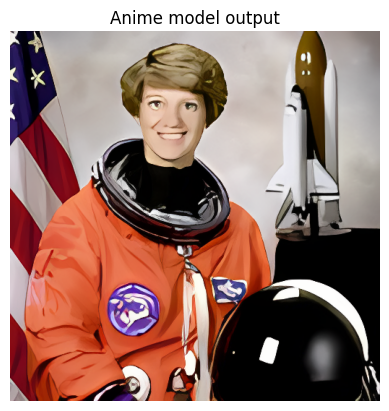

In [8]:
name = sample_names[0]
lr_bgr = cv2.cvtColor(lr_images[name], cv2.COLOR_RGB2BGR)
anime_output, _ = upsampler_anime.enhance(lr_bgr, outscale=4)
cv2.imwrite(f"samples/{name}_anime_upscaled.png", anime_output)
plt.imshow(cv2.cvtColor(anime_output, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Anime model output")
plt.show()

## Metrics — PSNR / SSIM vs ground truth

In [9]:
for name in sample_names:
    gt = gt_images[name]
    out = results[name]
    if gt.shape != out.shape:
        out = cv2.resize(out, (gt.shape[1], gt.shape[0]))
    p = psnr(gt, out, data_range=255)
    s = ssim(gt, out, channel_axis=2, data_range=255)
    print(f"{name:12s} PSNR={p:6.2f} dB   SSIM={s:.4f}")

astronaut    PSNR= 22.81 dB   SSIM=0.7777
cat          PSNR= 26.02 dB   SSIM=0.7196
coffee       PSNR= 24.43 dB   SSIM=0.6893
chelsea      PSNR= 26.02 dB   SSIM=0.7196
rocket       PSNR= 24.73 dB   SSIM=0.7871


## Side-by-side comparison

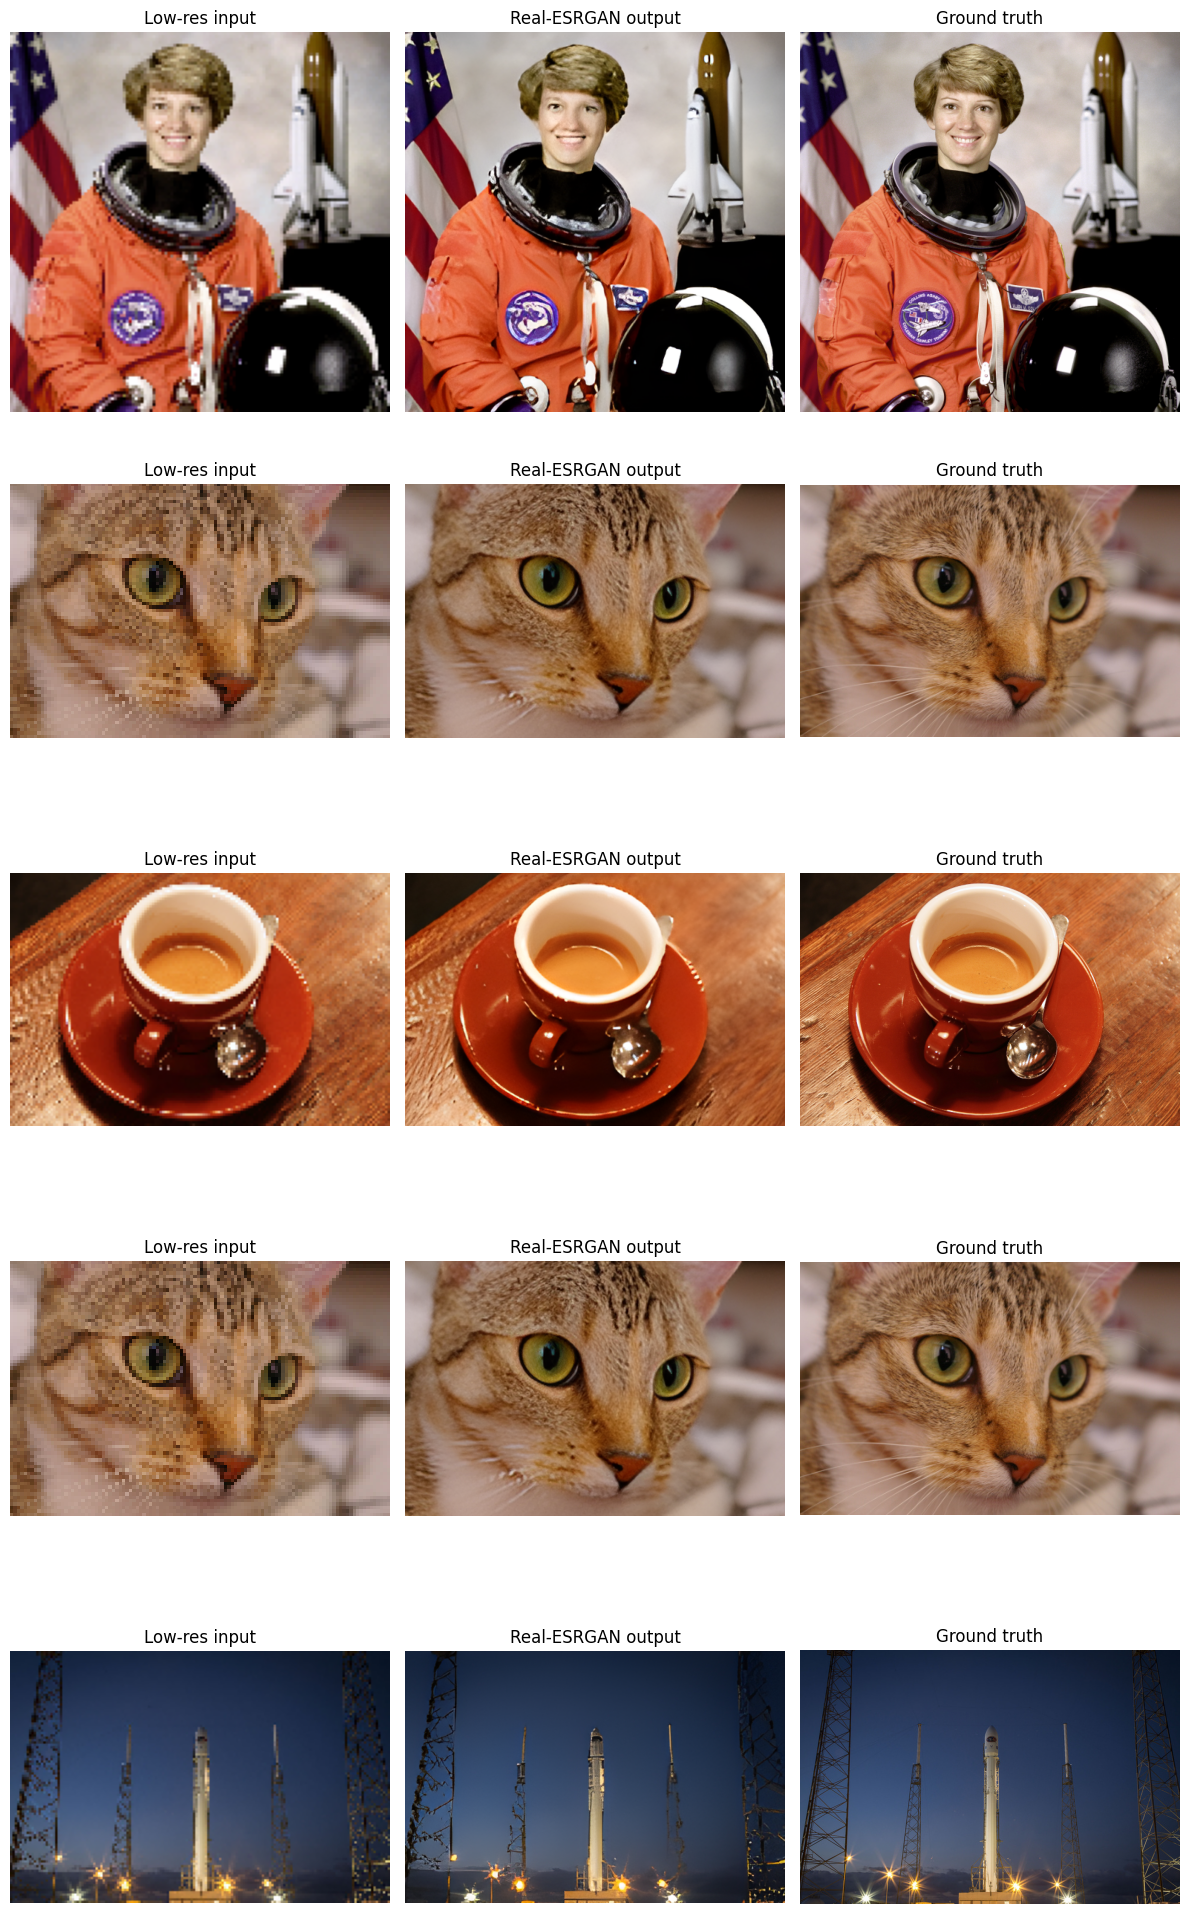

In [10]:
fig, axes = plt.subplots(len(sample_names), 3, figsize=(12, 4 * len(sample_names)))
for i, name in enumerate(sample_names):
    axes[i, 0].imshow(lr_images[name]); axes[i, 0].set_title("Low-res input"); axes[i, 0].axis("off")
    axes[i, 1].imshow(results[name]); axes[i, 1].set_title("Real-ESRGAN output"); axes[i, 1].axis("off")
    axes[i, 2].imshow(gt_images[name]); axes[i, 2].set_title("Ground truth"); axes[i, 2].axis("off")
plt.tight_layout()
plt.savefig("samples/comparison_grid.png", dpi=120)
plt.show()